# **CO2 Emissions Prediction**

**Name:** Tasneem Ashour, Berlanti Masalha, Batool Basalat  
**Course:** Introduction to Machine Learning  


## Introduction

Climate change and environmental pollution have become major global concerns in recent years. One of the main contributors to air pollution is vehicle carbon dioxide (CO2) emissions. Predicting CO2 emissions based on vehicle characteristics can help governments, manufacturers, and consumers better understand environmental impacts and support cleaner transportation decisions.

In this project, machine learning techniques are used to predict CO2 emissions produced by vehicles using a dataset containing different car specifications such as engine size, cylinders, fuel consumption, transmission type, and fuel type.

The main objective of this project is to compare multiple machine learning regression models and determine which model provides the best prediction performance.

The following regression models are used in this project:

- Linear Regression
- Ridge Regression
- Support Vector Regression (SVR)
- Decision Tree Regressor
- Random Forest Regressor

The models will be evaluated and compared using several performance metrics including:

- R² Score
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

The best-performing model will be selected based on prediction accuracy and error reduction.

# Part 1: Data Understanding & Problem Definition

In this project, a CO2 emissions dataset for vehicles is analyzed to understand the relationship between vehicle characteristics and carbon dioxide emissions. The dataset contains information such as engine size, cylinders, fuel consumption, transmission type, and fuel type.

The main goal of this project is to build and compare multiple machine learning regression models in order to predict vehicle CO2 emissions accurately and identify the best-performing model.

## 1.1 Import Required Libraries

In this section, the required Python libraries for data analysis, visualization, preprocessing, and machine learning are imported.

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GridSearchCV

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

## 1.2 Load the Dataset

The dataset is loaded into a Pandas DataFrame to begin data exploration and preprocessing.

In [49]:
# File path
PROJECT_ROOT_DIR = "."
file_path = os.path.join(PROJECT_ROOT_DIR, "datasets", "CO2_Emissions.csv")

# Load dataset (let pandas read original headers first)
df = pd.read_csv(file_path)


### Rename Columns

In [50]:
df.columns = [
    "make",
    "model",
    "vehicle_class",
    "engine_size",
    "cylinders",
    "transmission",
    "fuel_type",
    "fuel_consumption_city",
    "fuel_consumption_hwy",
    "fuel_consumption_comb",
    "fuel_consumption_mpg",
    "co2_emissions"
]

# 1.3 Dataset Information

This section displays basic information about the dataset including:
- Number of rows and columns
- Data types
- Missing values

### Dataset dimensions 

In [51]:
df.shape

(7385, 12)

### First 10 Rows
Preview the first 10 records of the dataset.

In [52]:
df.head(10)

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb,fuel_consumption_mpg,co2_emissions
0,TOYOTA,'4Runner 4WD (Part-Time 4WD)','SUV - STANDARD',4.0,6.0,AS5,X,14.3,11.9,13.2,21.0,308
1,KIA,RIO,COMPACT,1.6,4.0,AS6,X,8.8,6.5,7.8,36.0,181
2,GMC,'YUKON DENALI 4WD','SUV - STANDARD',6.2,8.0,A6,Z,16.2,11.4,14.0,20.0,322
3,DODGE,CHALLENGER,MID-SIZE,3.6,6.0,A8,X,12.4,7.8,10.3,27.0,242
4,MINI,'Cooper 5 Door',SUBCOMPACT,1.5,3.0,M6,Z,8.4,6.3,7.5,38.0,175
5,FORD,'F-150 FFV 4X4','PICKUP TRUCK - STANDARD',NaN,8.0,AS10,E,20.3,14.7,17.8,16.0,296
6,'LAND ROVER','RANGE ROVER SPORT V6 3.0 SC FFV','SUV - STANDARD',3.0,6.0,AS8,Z,14.2,10.2,12.4,23.0,285
7,MINI,'John Cooper Works Countryman ALL4',MID-SIZE,2.0,4.0,AS8,Z,10.0,7.8,9.0,31.0,210
8,CHEVROLET,EQUINOX,'SUV - SMALL',3.6,6.0,A6,E,18.8,13.1,16.2,17.0,259
9,GMC,ACADIA,'SUV - STANDARD',3.6,6.0,A6,X,14.3,9.9,12.3,23.0,283


### Data Types
Check the data types of each column.

In [53]:
df.dtypes

make                         str
model                        str
vehicle_class                str
engine_size              float64
cylinders                float64
transmission                 str
fuel_type                    str
fuel_consumption_city    float64
fuel_consumption_hwy     float64
fuel_consumption_comb    float64
fuel_consumption_mpg     float64
co2_emissions              int64
dtype: object

### Descriptive Statistics
Summary statistics for numerical features.

In [54]:
df.describe()

,engine_size,cylinders,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb,fuel_consumption_mpg,co2_emissions
count,7255.000000,7242.000000,7247.000000,7243.000000,7229.000000,7242.000000,7385.000000
mean,3.153908,5.572908,12.485732,9.008960,10.923682,27.499033,249.421530
std,1.327071,1.796051,3.426506,2.185903,2.840930,6.979348,56.040462
min,1.000000,3.000000,4.300000,4.500000,4.500000,11.000000,105.000000
25%,2.000000,4.000000,10.100000,7.500000,9.000000,23.000000,209.000000
50%,3.000000,6.000000,12.000000,8.700000,10.500000,27.000000,244.000000
75%,3.600000,6.000000,14.400000,10.100000,12.400000,31.000000,284.000000
max,6.800000,12.000000,30.300000,20.500000,25.900000,63.000000,493.000000


### Missing Values
Check if there are missing values in the dataset that need to be handled during preprocessing.

In [55]:
df.isnull().sum()

make                     148
model                    130
vehicle_class            175
engine_size              130
cylinders                143
transmission             165
fuel_type                134
fuel_consumption_city    138
fuel_consumption_hwy     142
fuel_consumption_comb    156
fuel_consumption_mpg     143
co2_emissions              0
dtype: int64

### Observations

- The dataset contains 7385 vehicles and 12 features.
- Several columns contain missing values (e.g., Make, Model, Vehicle Class, Engine Size, Cylinders, Transmission, Fuel Type, and the fuel consumption columns).
- The target variable is **CO2 Emissions (g/km)**, which is continuous, making this a **regression** problem.
- Features include a mix of numerical (engine size, cylinders, fuel consumption) and categorical (make, model, vehicle class, transmission, fuel type) variables.

This initial exploration helps us understand the dataset before preprocessing.

## 1.4 Exploratory Data Analysis

In this section, we use visualizations to understand relationships between features and the target variable. These plots help identify patterns that may be useful for prediction.

### 1. Distribution of CO2 Emissions

This histogram shows the distribution of CO2 emission values in the dataset.

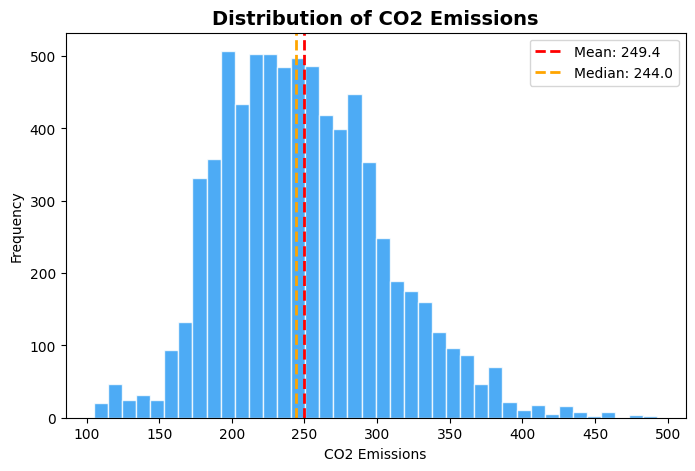

In [56]:
plt.figure(figsize=(8,5))

plt.hist(
    df['co2_emissions'],
    bins=40,
    color='#2196F3',
    edgecolor='white',
    alpha=0.8
)

plt.title(
    'Distribution of CO2 Emissions',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('CO2 Emissions')
plt.ylabel('Frequency')

# Mean line
plt.axvline(
    df['co2_emissions'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean: {df['co2_emissions'].mean():.1f}"
)

# Median line
plt.axvline(
    df['co2_emissions'].median(),
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f"Median: {df['co2_emissions'].median():.1f}"
)

plt.legend()

plt.show()

The histogram above shows the distribution of vehicle CO2 emissions in the dataset.

The red dashed line represents the mean CO2 emissions value, while the orange dashed line represents the median value.

The distribution appears slightly right-skewed, indicating that most vehicles produce moderate CO2 emissions, while a smaller number of vehicles generate very high emissions.

Key observations:
- The average CO2 emissions are approximately 249 g/km.
- The median CO2 emissions are approximately 244 g/km.
- Most vehicles fall within the range of 180–300 g/km.
- A few vehicles produce extremely high emissions above 400 g/km, which may be considered outliers.

### 2. CO2 Emissions Boxplot


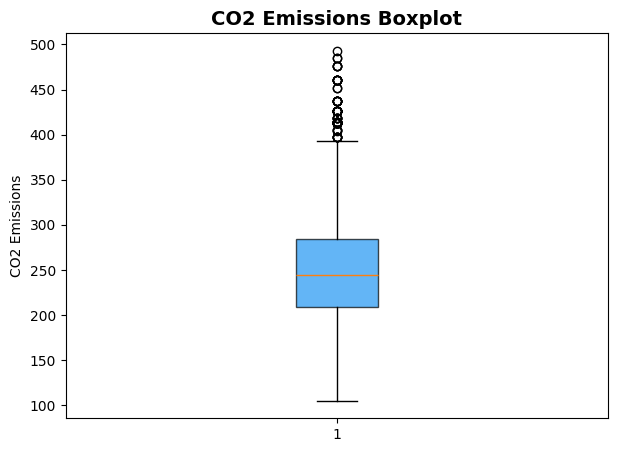

In [57]:
plt.figure(figsize=(7,5))

plt.boxplot(
    df['co2_emissions'].dropna(),
    patch_artist=True,
    boxprops=dict(
        facecolor='#2196F3',
        alpha=0.7
    )
)

plt.title(
    'CO2 Emissions Boxplot',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('CO2 Emissions')

plt.show()

The boxplot above summarizes the distribution of CO2 emissions and helps identify the spread of the data and potential outliers.

Key observations:
- The median CO2 emissions value is approximately 244 g/km.
- Most vehicles have CO2 emissions between 210 and 280 g/km.
- The dataset contains several high-emission outliers above 400 g/km.
- The wide spread of the boxplot indicates variability in vehicle emissions across different vehicle types and engine sizes.
- The presence of outliers suggests that some vehicles produce significantly higher emissions than the majority of vehicles in the dataset.

### 3. Engine Size and Cylinders vs CO2 Emissions



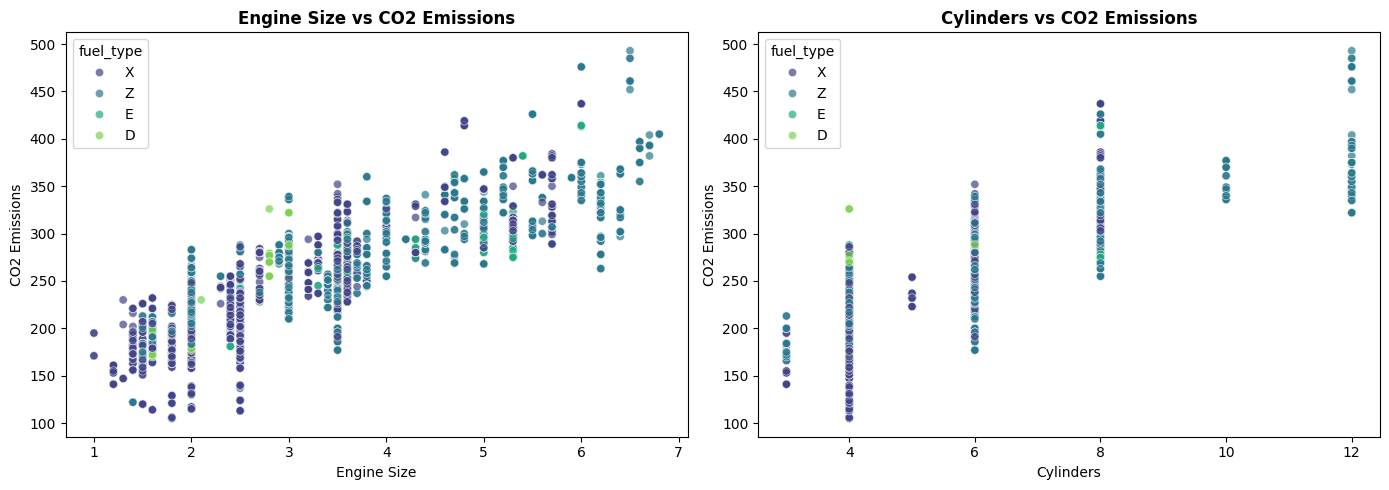

In [58]:
# Engine Size and Cylinders vs CO2 Emissions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Engine Size
sns.scatterplot(
    data=df,
    x='engine_size',
    y='co2_emissions',
    hue='fuel_type',
    palette='viridis',
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title(
    'Engine Size vs CO2 Emissions',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel('Engine Size')
axes[0].set_ylabel('CO2 Emissions')

# Cylinders
sns.scatterplot(
    data=df,
    x='cylinders',
    y='co2_emissions',
    hue='fuel_type',
    palette='viridis',
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title(
    'Cylinders vs CO2 Emissions',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel('Cylinders')
axes[1].set_ylabel('CO2 Emissions')

plt.tight_layout()

plt.show()

The scatter plots above illustrate the relationship between engine characteristics and CO2 emissions.

#### Engine Size vs CO2 Emissions
The left plot shows a strong positive relationship between engine size and CO2 emissions. Vehicles with larger engine sizes generally produce higher CO2 emissions. Most low-emission vehicles are associated with smaller engines, while larger engines tend to generate significantly higher emissions.

#### Cylinders vs CO2 Emissions
The right plot shows that vehicles with more cylinders usually produce higher CO2 emissions. Cars with 8, 10, and 12 cylinders tend to have the highest emission levels compared to vehicles with fewer cylinders.

#### Key Observations
- CO2 emissions increase as engine size increases.
- Vehicles with more cylinders generally consume more fuel and emit more CO2.
- Fuel type also affects emission levels, as shown by the different colors in the plots.
- High-performance vehicles with large engines and many cylinders are associated with the highest emission values.

### 4. Fuel Consumption Comparison and CO2 Emissions


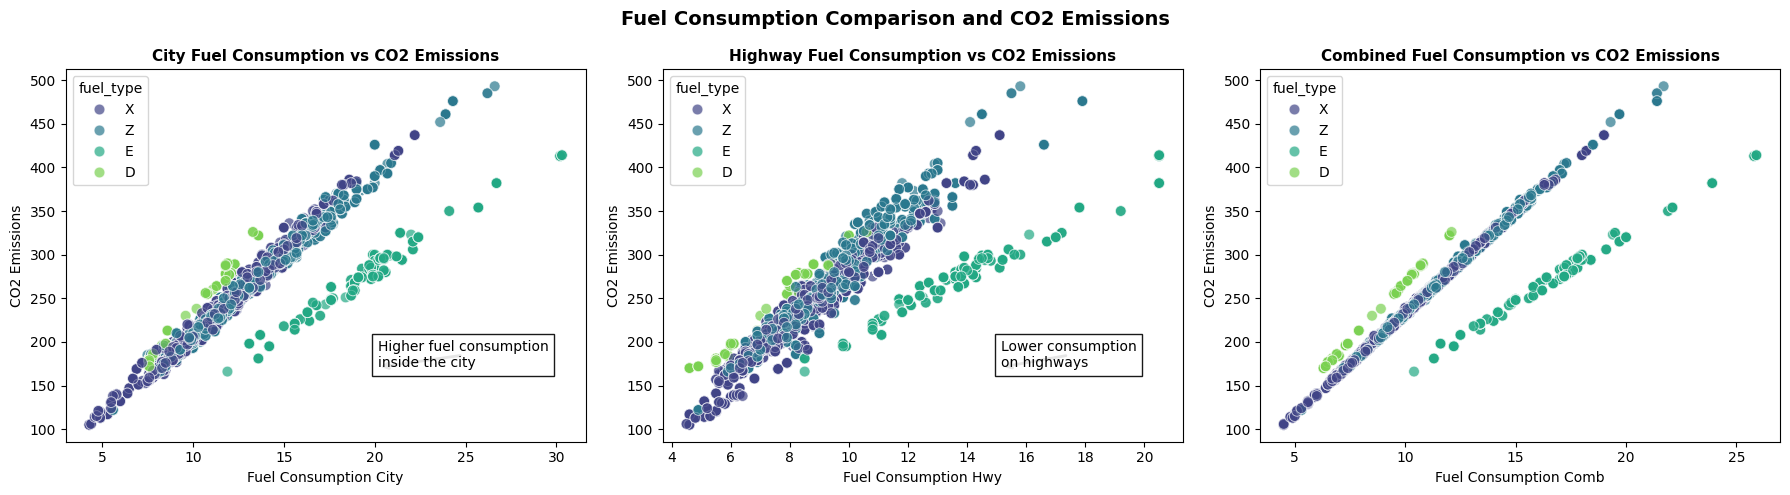

In [59]:
# Fuel Consumption Features vs CO2 Emissions

fuel_features = [
    'fuel_consumption_city',
    'fuel_consumption_hwy',
    'fuel_consumption_comb'
]

titles = [
    'City Fuel Consumption vs CO2 Emissions',
    'Highway Fuel Consumption vs CO2 Emissions',
    'Combined Fuel Consumption vs CO2 Emissions'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(fuel_features):

    sns.scatterplot(
        data=df,
        x=feat,
        y='co2_emissions',
        hue='fuel_type',
        palette='viridis',
        alpha=0.7,
        s=60,   # bigger points
        ax=axes[i]
    )

    axes[i].set_title(
        titles[i],
        fontsize=11,
        fontweight='bold'
    )

    axes[i].set_xlabel(feat.replace('_', ' ').title())
    axes[i].set_ylabel('CO2 Emissions')

# Highlight city consumption
axes[0].annotate(
    'Higher fuel consumption\ninside the city',
    xy=(0.60, 0.20),
    xycoords='axes fraction',
    fontsize=10,
    color='black',
    bbox=dict(
        facecolor='white',
        alpha=0.9,
        edgecolor='black'
    ),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=2
    )
)

# Highlight highway efficiency
axes[1].annotate(
    'Lower consumption\non highways',
    xy=(0.65, 0.20),
    xycoords='axes fraction',
    fontsize=10,
    color='black',
    bbox=dict(
        facecolor='white',
        alpha=0.9,
        edgecolor='black'
    ),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=2
    )
)

# General comparison note
fig.suptitle(
    'Fuel Consumption Comparison and CO2 Emissions',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

The scatter plots above compare different types of fuel consumption with CO2 emissions.

#### City Fuel Consumption vs CO2 Emissions
The first plot shows a strong positive relationship between fuel consumption inside the city and CO2 emissions. Vehicles that consume more fuel in city driving conditions generally produce higher CO2 emissions.

#### Highway Fuel Consumption vs CO2 Emissions
The second plot illustrates that highway fuel consumption is generally lower than city fuel consumption. Although CO2 emissions still increase with fuel usage, vehicles tend to consume less fuel on highways due to smoother driving conditions and fewer stops.

#### Combined Fuel Consumption vs CO2 Emissions
The combined fuel consumption plot shows one of the strongest linear relationships with CO2 emissions. This indicates that combined fuel consumption is a highly important feature for predicting vehicle CO2 emissions.

#### Key Observations
- Higher fuel consumption leads to higher CO2 emissions.
- City driving conditions usually result in greater fuel consumption than highway driving.
- Combined fuel consumption has a very strong correlation with CO2 emissions.
- Fuel type influences both fuel consumption and emission levels, as shown by the different colored groups.

### 5. Average CO2 Emissions by Fuel Type


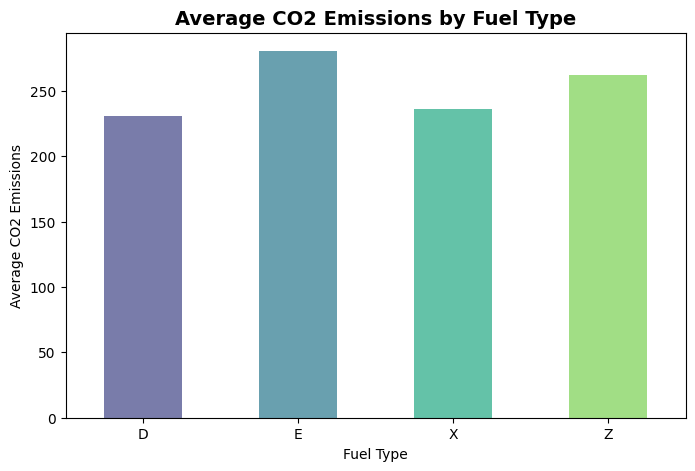

In [60]:

avg_co2 = df.groupby("fuel_type")["co2_emissions"].mean()

fuel_colors = ['#797CAA', '#69A0AF', '#64C2A8', '#A1DE85']

plt.figure(figsize=(8,5))

avg_co2.plot(
    kind='bar',
    color=fuel_colors[:len(avg_co2)]
)

plt.title(
    "Average CO2 Emissions by Fuel Type",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Fuel Type")
plt.ylabel("Average CO2 Emissions")

plt.xticks(rotation=0)

plt.show()

The bar chart above compares the average CO2 emissions produced by different fuel types.

#### Key Observations
- Fuel type **E** has the highest average CO2 emissions among all fuel types.
- Fuel type **Z** also produces relatively high CO2 emissions compared to the other fuel types.
- Fuel types **D** and **X** have lower average emission levels.
- The differences between fuel types indicate that fuel composition and engine efficiency significantly affect vehicle emissions.

Overall, fuel type appears to be an important factor influencing vehicle CO2 emissions and should be considered during model training and prediction.

### 6. Correlation Heatmap

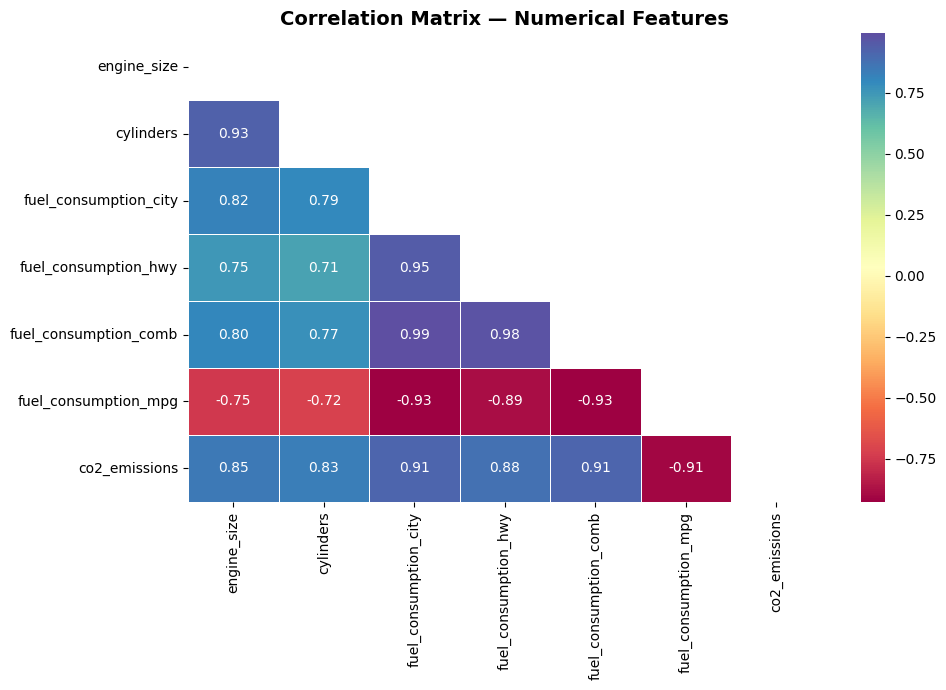

In [61]:
# Correlation Heatmap - Numerical Features

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(10, 7))

corr = df[numeric_cols].corr()

# Upper triangle mask
mask = np.triu(
    np.ones_like(corr, dtype=bool)
)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Spectral',
    mask=mask,
    linewidths=0.5,
    annot_kws={'size': 10}
)

plt.title(
    'Correlation Matrix — Numerical Features',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.show()


#### Key Observations
- Fuel consumption features show a very strong positive correlation with CO2 emissions, especially:
  - `fuel_consumption_city`
  - `fuel_consumption_hwy`
  - `fuel_consumption_comb`

- Combined fuel consumption has one of the highest correlations with CO2 emissions (approximately 0.91), making it a highly important feature for prediction.

- Engine size and number of cylinders also have strong positive correlations with CO2 emissions:
  - `engine_size` → 0.85
  - `cylinders` → 0.83

- Fuel consumption in MPG has a strong negative correlation with CO2 emissions (-0.91). This means vehicles with better fuel efficiency generally produce lower CO2 emissions.

Overall, the heatmap confirms that fuel consumption, engine size, and cylinders are among the most influential factors affecting vehicle CO2 emissions.

### 7. Average CO2 Emissions by Vehicle Class


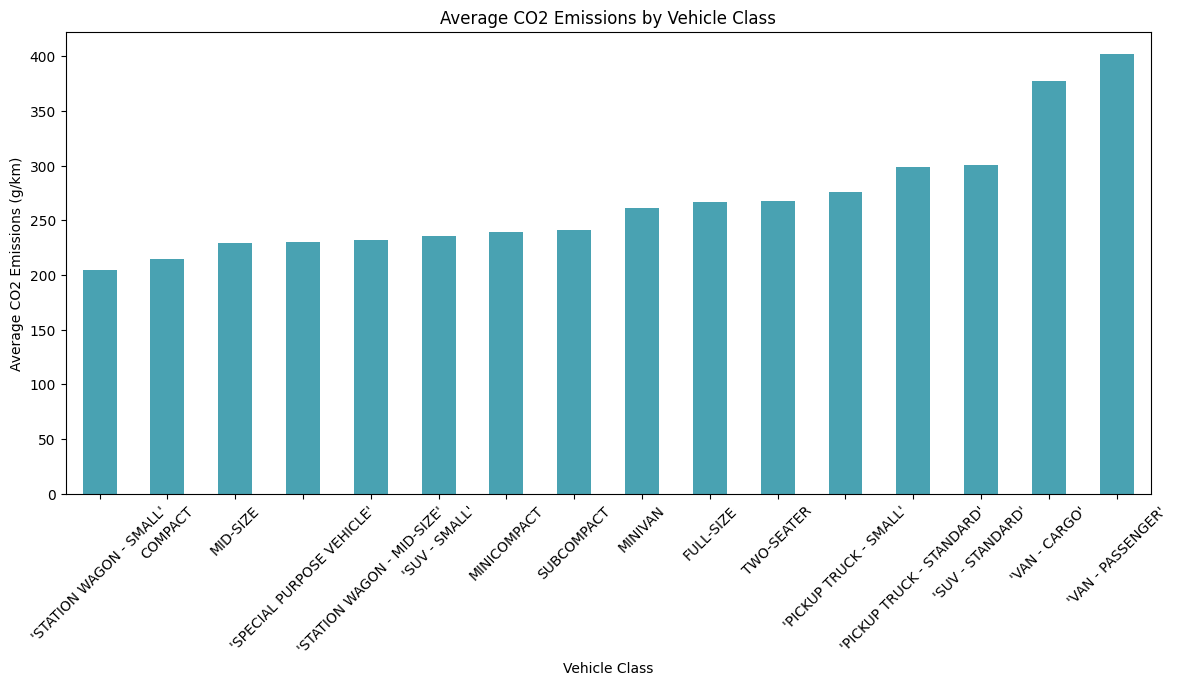

In [62]:
avg_vehicle = df.groupby(
    "vehicle_class"
)["co2_emissions"].mean().sort_values()

plt.figure(figsize=(14,6))

avg_vehicle.plot(
    kind="bar",
    color="#49A2B2"
)

plt.title("Average CO2 Emissions by Vehicle Class")

plt.xlabel("Vehicle Class")
plt.ylabel("Average CO2 Emissions (g/km)")

plt.xticks(rotation=45)

plt.show()

The bar chart above compares the average CO2 emissions across different vehicle classes.

#### Key Observations
- Larger vehicle classes such as:
  - `VAN - PASSENGER`
  - `VAN - CARGO`
  - `SUV - STANDARD`
  
  produce the highest average CO2 emissions.

- vehicle classes such as:
  - `COMPACT`
  - `MID-SIZE`
  - `SUBCOMPACT`
  
  generally produce lower CO2 emissions.

- Pickup trucks and larger SUVs tend to generate higher emissions due to larger engines and higher fuel consumption.

- Vehicle size and weight appear to strongly influence CO2 emissions, as heavier vehicles typically require more fuel and produce more emissions.

Overall, the visualization shows that larger and less fuel-efficient vehicle classes contribute more significantly to CO2 emissions.

# Part 2: Data Preprocessing

In this section, the dataset is prepared for machine learning model training. Data preprocessing includes selecting relevant features, encoding categorical variables, splitting the dataset into training and testing sets, and scaling numerical features when necessary.

## 2.1 Handling Missing Values

### Step 1: Checking missing values
We count the number of missing values in each feature.

In [63]:
missing_values = df.isnull().sum()
missing_values

make                     148
model                    130
vehicle_class            175
engine_size              130
cylinders                143
transmission             165
fuel_type                134
fuel_consumption_city    138
fuel_consumption_hwy     142
fuel_consumption_comb    156
fuel_consumption_mpg     143
co2_emissions              0
dtype: int64

### Missing Values Analysis

Before training the model, the dataset was examined for missing values. Several features contain missing data:

- **Make** (148 missing), **Model** (130 missing), **Vehicle Class** (175 missing), **Transmission** (165 missing), and **Fuel Type** (134 missing) are categorical features — they will be imputed using the **mode** (most frequent value).

- **Engine Size(L)** (130 missing), **Cylinders** (143 missing), and all **Fuel Consumption** columns have numerical missing values — they will be imputed using the **median** to reduce the effect of outliers.

- The target column **CO2 Emissions(g/km)** has **no missing values** and requires no imputation.

After handling these missing values, the dataset will be complete and ready for preprocessing and model training.

### Step 2: Numerical feature imputation
We use median for numerical features to reduce the effect of outliers.

In [64]:
numerical_cols = [
    "engine_size",
    "cylinders",
    "fuel_consumption_city",
    "fuel_consumption_hwy",
    "fuel_consumption_comb",
    "fuel_consumption_mpg"
]

for col in numerical_cols:
    
    df[col] = df[col].fillna(
        df[col].median()
    )

### Step 3: Categorical feature imputation
We use mode for categorical features.

In [65]:
categorical_cols = [
    "make",
    "model",
    "vehicle_class",
    "transmission",
    "fuel_type"
]

for col in categorical_cols:
    
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

### Step 4: Verifying no missing values remain

In [66]:
df.isnull().sum()

make                     0
model                    0
vehicle_class            0
engine_size              0
cylinders                0
transmission             0
fuel_type                0
fuel_consumption_city    0
fuel_consumption_hwy     0
fuel_consumption_comb    0
fuel_consumption_mpg     0
co2_emissions            0
dtype: int64

### 2.3 Drop Duplicate Records

Data quality is an important step in any Machine Learning and data analysis project.  
Before training the models, the dataset was checked for duplicate records to ensure that the data is clean and reliable.

The following code was used to detect duplicated rows:

In [67]:
df.duplicated().sum()

np.int64(4887)

This means that the dataset contained 4887 duplicated rows.

Duplicate records can negatively affect the analysis and model performance because repeated data may bias the learning process and produce inaccurate results. In addition, duplicates increase the dataset size unnecessarily and may lead to overfitting in some machine learning models.

To solve this issue, the duplicated rows were removed using:

In [68]:
df.drop_duplicates(inplace=True)

The drop_duplicates() function removes all repeated rows from the dataset, while inplace=True applies the changes directly to the original DataFrame without creating a new copy.

After removing duplicates, the dataset became cleaner and more suitable for accurate analysis and model training.

## 2.2 Feature Encoding

In this section, categorical features are identified and appropriate encoding techniques are applied based on the nature of each feature.

### Step 1: Identifying Categorical Features

The categorical features in the dataset are divided into two groups:

### High-Cardinality Features (Dropped)
- `make`
- `model`

These features contain a large number of unique values, which would significantly increase the number of generated columns after encoding. To avoid dimensionality explosion and reduce model complexity, these features are removed from the dataset.

---

### Nominal Features (One-Hot Encoding)
- `vehicle_class`
- `fuel_type`
- `transmission`

These features do not contain any natural order or ranking. Therefore, One-Hot Encoding is applied to convert them into numerical format suitable for machine learning models.

### Step 2: Drop High-Cardinality Features

In [69]:
df = df.drop(columns=['make', 'model'])
print("Shape after dropping high-cardinality features:", df.shape)

Shape after dropping high-cardinality features: (2498, 10)


### Step 3: Applying One-Hot Encoding
We apply One-Hot Encoding to nominal features (Vehicle Class, Fuel Type, Transmission).

In [70]:
print("Shape before encoding:", df.shape)

Shape before encoding: (2498, 10)


In [71]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "vehicle_class",
        "fuel_type",
        "transmission"
    ],
    drop_first=True
)

In [72]:
print("Shape after encoding:", df_encoded.shape)

Shape after encoding: (2498, 48)


#### Sample of Encoded Data

In [73]:
df_encoded.head()

,engine_size,cylinders,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb,fuel_consumption_mpg,co2_emissions,vehicle_class_'PICKUP TRUCK - STANDARD',vehicle_class_'SPECIAL PURPOSE VEHICLE',vehicle_class_'STATION WAGON - MID-SIZE',...,transmission_AS8,transmission_AS9,transmission_AV,transmission_AV10,transmission_AV6,transmission_AV7,transmission_AV8,transmission_M5,transmission_M6,transmission_M7
0,4.0,6.0,14.3,11.9,13.2,21.0,308,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.6,4.0,8.8,6.5,7.8,36.0,181,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,6.2,8.0,16.2,11.4,14.0,20.0,322,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3.6,6.0,12.4,7.8,10.3,27.0,242,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.5,3.0,8.4,6.3,7.5,38.0,175,False,False,False,...,False,False,False,False,False,False,False,False,True,False


### Summary of Encoding Decisions

- High-cardinality features (Make, Model) were dropped to avoid dimensionality problems.
- Nominal categorical features (Vehicle Class, Fuel Type, Transmission) were encoded using One-Hot Encoding to avoid introducing incorrect ordinal relationships.
- Numerical features were kept as-is, as they are already in a suitable format.

## 2.4 Train-Test Split

We split the dataset into training and testing sets.

### Configuration:
- Training set: 80%
- Testing set: 20%
- random_state=42 ensures reproducibility


In [74]:
X = df_encoded.drop("co2_emissions", axis=1)

y = df_encoded["co2_emissions"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [75]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1998, 47)
Testing set size: (500, 47)


In [76]:
print("Training target stats:")
print(y_train.describe())

print("\nTesting target stats:")
print(y_test.describe())

Training target stats:
count    1998.000000
mean      249.654154
std        56.673414
min       105.000000
25%       207.000000
50%       243.000000
75%       286.000000
max       493.000000
Name: co2_emissions, dtype: float64

Testing target stats:
count    500.00000
mean     248.03600
std       58.52782
min      105.00000
25%      205.75000
50%      243.00000
75%      286.00000
max      461.00000
Name: co2_emissions, dtype: float64


## 2.3 Feature Scaling

We apply StandardScaler to all numerical features in the dataset.

### Why Scaling is Important for Linear Regression:
- Linear Regression is sensitive to feature magnitudes.
- Features with large values (e.g., fuel consumption in L/100 km) can dominate over smaller-valued features.
- Scaling improves numerical stability during optimization.
- It ensures all features contribute fairly to the prediction.

### Important:
The scaler must be fitted ONLY on training data to avoid data leakage.

In [77]:
from sklearn.preprocessing import StandardScaler

# Apply feature scaling using StandardScaler
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Only transform test data to avoid data leakage

In [78]:
# Check mean and standard deviation before scaling
print("Before Scaling (Training Data)")

print("\nMean:")
print(X_train.mean())

print("\nStandard Deviation:")
print(X_train.std())

Before Scaling (Training Data)

Mean:
engine_size                                  3.144144
cylinders                                    5.598098
fuel_consumption_city                       12.503604
fuel_consumption_hwy                         9.031281
fuel_consumption_comb                       10.941091
fuel_consumption_mpg                        27.375876
vehicle_class_'PICKUP TRUCK - STANDARD'      0.063564
vehicle_class_'SPECIAL PURPOSE VEHICLE'      0.013514
vehicle_class_'STATION WAGON - MID-SIZE'     0.004004
vehicle_class_'STATION WAGON - SMALL'        0.044044
vehicle_class_'SUV - SMALL'                  0.224224
vehicle_class_'SUV - STANDARD'               0.104104
vehicle_class_'VAN - CARGO'                  0.001001
vehicle_class_'VAN - PASSENGER'              0.006507
vehicle_class_COMPACT                        0.129129
vehicle_class_FULL-SIZE                      0.069069
vehicle_class_MID-SIZE                       0.139640
vehicle_class_MINICOMPACT                   

In [79]:
# Convert scaled training data to DataFrame for easier inspection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Check mean and standard deviation after scaling
print("After Scaling (Training Data)")

print("\nMean:")
print(X_train_scaled_df.mean())

print("\nStandard Deviation:")
print(X_train_scaled_df.std())

After Scaling (Training Data)

Mean:
engine_size                                 1.653666e-16
cylinders                                   1.546977e-16
fuel_consumption_city                      -2.400482e-16
fuel_consumption_hwy                        1.884823e-16
fuel_consumption_comb                       2.542733e-16
fuel_consumption_mpg                       -2.009293e-16
vehicle_class_'PICKUP TRUCK - STANDARD'     4.978778e-17
vehicle_class_'SPECIAL PURPOSE VEHICLE'     5.334405e-18
vehicle_class_'STATION WAGON - MID-SIZE'    1.422508e-17
vehicle_class_'STATION WAGON - SMALL'       2.311575e-17
vehicle_class_'SUV - SMALL'                -5.089911e-17
vehicle_class_'SUV - STANDARD'              2.578296e-17
vehicle_class_'VAN - CARGO'                -1.244694e-17
vehicle_class_'VAN - PASSENGER'            -8.890675e-18
vehicle_class_COMPACT                       4.978778e-17
vehicle_class_FULL-SIZE                    -2.845016e-17
vehicle_class_MID-SIZE                     -5.24549

# Part 3: Model Training & Evaluation

In this section, multiple machine learning regression models are trained and evaluated to predict vehicle CO2 emissions.

The models are compared using different evaluation metrics, including:
- R² Score
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

The main goal is to identify the model that provides the most accurate predictions and the lowest prediction error.

### 3.1 Linear Regression

Linear Regression is used as a baseline model to predict CO2 emissions using a linear relationship between the input features and the target variable.

In [80]:
# Linear Regression

linear_model = LinearRegression()

# Start timer

start_time = time.time()

# Train model

linear_model.fit(X_train_scaled, y_train)

# End timer

end_time = time.time()

linear_training_time = end_time - start_time

# Predictions

y_pred_linear = linear_model.predict(X_test_scaled)

# Evaluation Metrics

linear_r2 = r2_score(y_test, y_pred_linear)

linear_mae = mean_absolute_error(y_test, y_pred_linear)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

# Results

print("Linear Regression Results")
print(f"Training Time: {linear_training_time:.4f} seconds")
print("R² Score:", linear_r2)

print("MAE:", linear_mae)

print("RMSE:", linear_rmse)

Linear Regression Results
Training Time: 0.0436 seconds
R² Score: 0.9654150605031868
MAE: 6.869909983359243
RMSE: 10.873544320888925


### 3.2 Ridge Regression

Ridge Regression is an improved version of Linear Regression that applies L2 regularization to reduce overfitting and improve model generalization.

In this model, the optimal regularization parameter (`alpha`) is selected automatically using cross-validation. Different alpha values are tested, and the value that produces the best performance is chosen.

#### Selecting the Best Alpha Value

In this step, Cross-Validation is used to automatically find the best alpha value for Ridge Regression. Different alpha values are tested, and the value that gives the best performance is selected.

In [81]:
import time

# Start timer

start_time = time.time()

# Create RidgeCV model

ridge_cv = RidgeCV(
    alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    cv=5
)

# Train RidgeCV model

ridge_cv.fit(X_train_scaled, y_train)

# End timer

end_time = time.time()

ridge_cv_training_time = end_time - start_time

# Store the best alpha

best_alpha = ridge_cv.alpha_

# Results

print(f"Best Alpha Value: {best_alpha}")

print(f"Training Time: {ridge_cv_training_time:.4f} seconds")

Best Alpha Value: 1.0
Training Time: 0.1888 seconds


#### Training Ridge Regression Model

After selecting the optimal alpha value, the final Ridge Regression model is trained using the scaled training dataset.

In [82]:
import time

# Create Ridge Regression model

ridge_model = Ridge(alpha=best_alpha)

# Start timer

start_time = time.time()

# Train the model

ridge_model.fit(X_train_scaled, y_train)

# End timer

end_time = time.time()

ridge_training_time = end_time - start_time

# Make predictions

y_pred_ridge = ridge_model.predict(X_test_scaled)

# Evaluation Metrics

ridge_r2 = r2_score(y_test, y_pred_ridge)

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_ridge)
)

# Display Results

print("Ridge Regression Results")
print(f"Training Time: {ridge_training_time:.4f} seconds")
print("R² Score:", ridge_r2)

print("MAE:", ridge_mae)

print("RMSE:", ridge_rmse)

Ridge Regression Results
Training Time: 0.0032 seconds
R² Score: 0.9654356331803177
MAE: 6.87076180131995
RMSE: 10.87030980326175


### 3.3 Support Vector Machine (SVR)

#### Hyperparameter Tuning for SVR

Grid Search with Cross-Validation is used to find the best hyperparameter values for the Support Vector Regression (SVR) model.

Different combinations of:
- C
- gamma
- epsilon

are tested automatically, and the combination with the best performance is selected.

In [83]:
# Define parameter grid

param_grid = {
    'C': [1, 10, 100],
    'gamma': [0.01, 0.1, 1],
    'epsilon': [0.1, 0.5, 1]
}

# Create SVR model

svr = SVR(kernel='rbf')

# Grid Search with Cross Validation

grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Start timer

start_time = time.time()

# Train Grid Search

grid_search.fit(X_train_scaled, y_train)

# End timer

end_time = time.time()

svr_grid_training_time = end_time - start_time

# Best parameters

best_params = grid_search.best_params_

# Results

print("Best Parameters:", best_params)

print(f"Training Time: {svr_grid_training_time:.4f} seconds")

Best Parameters: {'C': 100, 'epsilon': 1, 'gamma': 0.01}
Training Time: 26.9913 seconds


#### Training Support Vector Regression (SVR)

After selecting the best hyperparameters, the final Support Vector Regression (SVR) model is trained and evaluated.

In [84]:

svr_model = SVR(
    kernel='rbf',
    C=best_params['C'],
    gamma=best_params['gamma'],
    epsilon=best_params['epsilon']
)

start_time = time.time()

svr_model.fit(X_train_scaled, y_train)
end_time = time.time()

svr_training_time = end_time - start_time
y_pred_svr = svr_model.predict(X_test_scaled)
svr_r2 = r2_score(y_test, y_pred_svr)

svr_mae = mean_absolute_error(y_test, y_pred_svr)

svr_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_svr)
)

# Display Results

print("SVR Results")
print(f"Training Time: {svr_training_time:.4f} seconds")

print(f"R² Score: {svr_r2:.4f}")
print(f"MAE: {svr_mae:.4f}")
print(f"RMSE: {svr_rmse:.4f}")

SVR Results
Training Time: 0.2702 seconds
R² Score: 0.9671
MAE: 5.5172
RMSE: 10.6021


### 5.4 Decision Tree

#### Hyperparameter Tuning for Decision Tree Regressor

Grid Search with Cross-Validation is used to find the best hyperparameter values for the Decision Tree Regressor.

Different combinations of:
- max_depth
- min_samples_split
- min_samples_leaf

are tested automatically to improve model performance and reduce overfitting.

In [85]:
# Define parameter grid

param_grid = {
    'max_depth': [5, 8, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Create Decision Tree model

dt = DecisionTreeRegressor(
    random_state=42
)

# Grid Search with Cross Validation

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Start timer

start_time = time.time()

# Train Grid Search

grid_search_dt.fit(X_train, y_train)

# End timer

end_time = time.time()

dt_grid_training_time = end_time - start_time

# Best parameters

best_dt_params = grid_search_dt.best_params_

# Results

print("Best Parameters:")
print(best_dt_params)

print(f"Training Time: {dt_grid_training_time:.4f} seconds")

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2}
Training Time: 1.5672 seconds


#### Training Decision Tree Regressor

After selecting the best hyperparameters, the final Decision Tree model is trained and evaluated.

In [86]:
dt_model = DecisionTreeRegressor(
    max_depth=best_dt_params['max_depth'],
    min_samples_split=best_dt_params['min_samples_split'],
    min_samples_leaf=best_dt_params['min_samples_leaf'],
    random_state=42
)

# Start timer

start_time = time.time()

# Train model

dt_model.fit(X_train, y_train)

# End timer

end_time = time.time()

dt_training_time = end_time - start_time

# Predictions

y_pred_dt = dt_model.predict(X_test)

# Evaluation Metrics

dt_r2 = r2_score(y_test, y_pred_dt)

dt_mae = mean_absolute_error(y_test, y_pred_dt)

dt_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_dt)
)

# Results

print("Decision Tree Results")
print(f"dt_training_time: {dt_training_time:.4f} seconds")
print(f"R² Score: {dt_r2:.4f}")
print(f"MAE: {dt_mae:.4f}")
print(f"RMSE: {dt_rmse:.4f}")

Decision Tree Results
dt_training_time: 0.0160 seconds
R² Score: 0.9440
MAE: 4.3540
RMSE: 13.8407


### 5.5 Random Forest

#### Hyperparameter Tuning for Random Forest Regressor

Grid Search with Cross-Validation is used to find the best hyperparameter values for the Random Forest Regressor.

Different combinations of:
- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf

are tested automatically to improve prediction accuracy and reduce overfitting.

In [87]:

# Define parameter grid

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create Random Forest model

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Grid Search with Cross Validation

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Start timer

start_time = time.time()

# Train Grid Search

grid_search_rf.fit(X_train, y_train)

# End timer

end_time = time.time()

rf_grid_training_time = end_time - start_time

# Best parameters

best_rf_params = grid_search_rf.best_params_

# Results

print("Best Parameters:")
print(best_rf_params)

print(f"Training Time: {rf_grid_training_time:.4f} seconds")

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Training Time: 37.0934 seconds


#### Training Random Forest Regressor

After selecting the best hyperparameters, the final Random Forest model is trained and evaluated.

In [88]:
rf_model = RandomForestRegressor(
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    min_samples_split=best_rf_params['min_samples_split'],
    min_samples_leaf=best_rf_params['min_samples_leaf'],
    random_state=42,
    n_jobs=-1
)

# Start timer

start_time = time.time()

# Train model

rf_model.fit(X_train, y_train)

# End timer

end_time = time.time()

rf_training_time = end_time - start_time

# Predictions

y_pred_rf = rf_model.predict(X_test)

# Evaluation Metrics

rf_r2 = r2_score(y_test, y_pred_rf)

rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

# Results

print("Random Forest Results")

print(f"Training Time: { rf_training_time:.4f} seconds")

print(f"R² Score: {rf_r2:.4f}")

print(f"MAE: {rf_mae:.4f}")

print(f"RMSE: {rf_rmse:.4f}")

Random Forest Results
Training Time: 0.4807 seconds
R² Score: 0.9754
MAE: 3.2139
RMSE: 9.1769


In [89]:
# Model Comparison Table

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'SVR',
        'Decision Tree',
        'Random Forest'
    ],

    'R² Score': [
        linear_r2,
        ridge_r2,
        svr_r2,
        dt_r2,
        rf_r2
    ],

    'MAE': [
        linear_mae,
        ridge_mae,
        svr_mae,
        dt_mae,
        rf_mae
    ],

    'RMSE': [
        linear_rmse,
        ridge_rmse,
        svr_rmse,
        dt_rmse,
        rf_rmse
    ],

    'Training Time (s)': [
        linear_training_time,
        ridge_training_time,
        svr_training_time,
        dt_training_time,
        rf_training_time
    ]
})

# Round values

results = results.round(4)

# Display table

print(results)

               Model  R² Score     MAE     RMSE  Training Time (s)
0  Linear Regression    0.9654  6.8699  10.8735             0.0436
1   Ridge Regression    0.9654  6.8708  10.8703             0.0032
2                SVR    0.9671  5.5172  10.6021             0.2702
3      Decision Tree    0.9440  4.3540  13.8407             0.0160
4      Random Forest    0.9754  3.2139   9.1769             0.4807


### Error Metrics Comparison

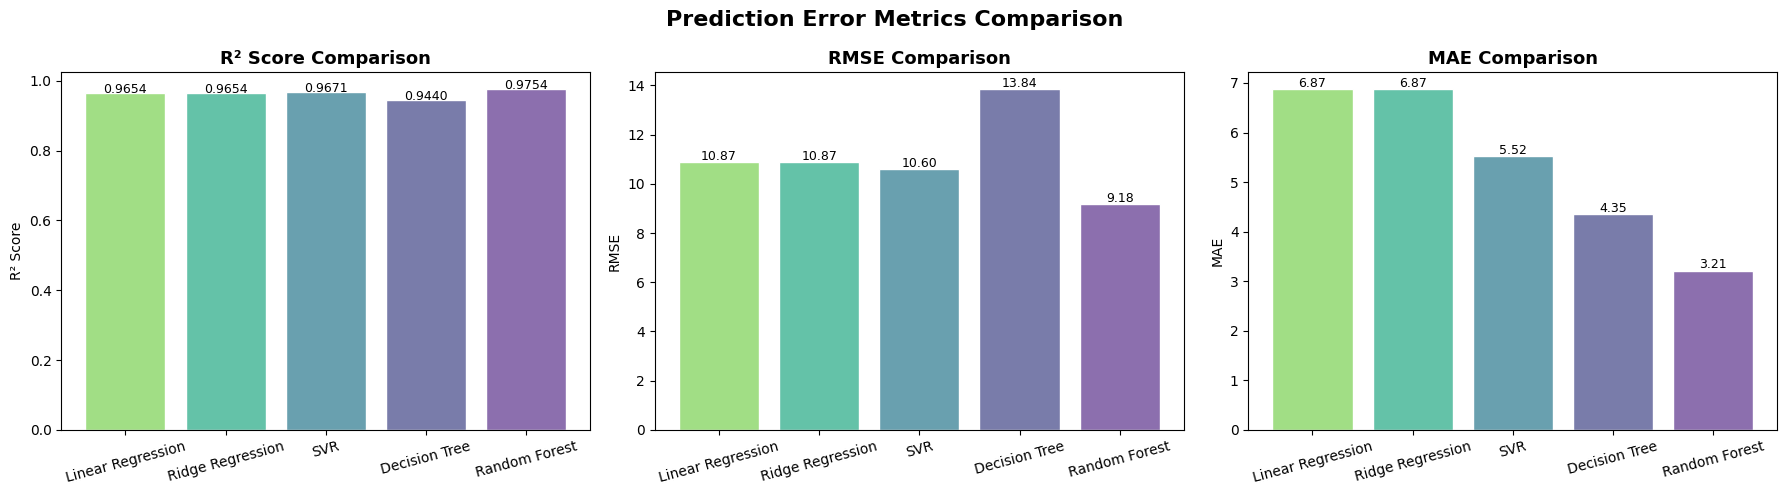

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#A1DE85', '#64C2A8', '#69A0AF', '#797CAA', '#8C6FAE']

# -------------------------------
# R² Score
# -------------------------------

axes[0].bar(
    results['Model'],
    results['R² Score'],
    color=colors,
    edgecolor='white'
)

axes[0].set_title(
    'R² Score Comparison',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_ylabel('R² Score')

axes[0].tick_params(axis='x', rotation=15)

for i, v in enumerate(results['R² Score']):

    axes[0].text(
        i,
        v + 0.0005,
        f'{v:.4f}',
        ha='center',
        fontsize=9
    )

# -------------------------------
# RMSE
# -------------------------------

axes[1].bar(
    results['Model'],
    results['RMSE'],
    color=colors,
    edgecolor='white'
)

axes[1].set_title(
    'RMSE Comparison',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_ylabel('RMSE')

axes[1].tick_params(axis='x', rotation=15)

for i, v in enumerate(results['RMSE']):

    axes[1].text(
        i,
        v + 0.1,
        f'{v:.2f}',
        ha='center',
        fontsize=9
    )

# -------------------------------
# MAE
# -------------------------------

axes[2].bar(
    results['Model'],
    results['MAE'],
    color=colors,
    edgecolor='white'
)

axes[2].set_title(
    'MAE Comparison',
    fontsize=13,
    fontweight='bold'
)

axes[2].set_ylabel('MAE')

axes[2].tick_params(axis='x', rotation=15)

for i, v in enumerate(results['MAE']):

    axes[2].text(
        i,
        v + 0.05,
        f'{v:.2f}',
        ha='center',
        fontsize=9
    )

plt.suptitle(
    'Prediction Error Metrics Comparison',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

### Prediction Error Metrics Interpretation

The comparison results demonstrate noticeable differences in the performance of the machine learning models. Random Forest Regressor achieved the best overall performance, obtaining the highest R² Score (0.9754) along with the lowest RMSE (9.18) and MAE (3.21) values. These results indicate that the model produced the most accurate predictions and was highly effective in minimizing prediction errors.

Decision Tree Regressor achieved the weakest overall performance among the evaluated models, producing the lowest R² Score (0.9440) and the highest RMSE value (13.84). This suggests that the model struggled to generalize effectively and generated larger prediction errors compared to the other models.

Support Vector Regression (SVR) demonstrated strong predictive capability, achieving better performance than the linear models with an R² Score of 0.9671 and lower error values. These results indicate that SVR was more successful in capturing nonlinear relationships within the dataset.

Linear Regression and Ridge Regression produced identical performance results, achieving an R² Score of 0.9654 with moderate RMSE and MAE values. Although both models explained a large portion of the variance in the target variable, their higher prediction errors compared to SVR and Random Forest suggest that purely linear approaches were less effective in modeling the complex relationships present in the dataset.

Overall, the results indicate that nonlinear and ensemble-based models were more suitable for predicting the target variable, as they were better able to capture complex feature interactions and reduce prediction error

### Time Comparison Visualization


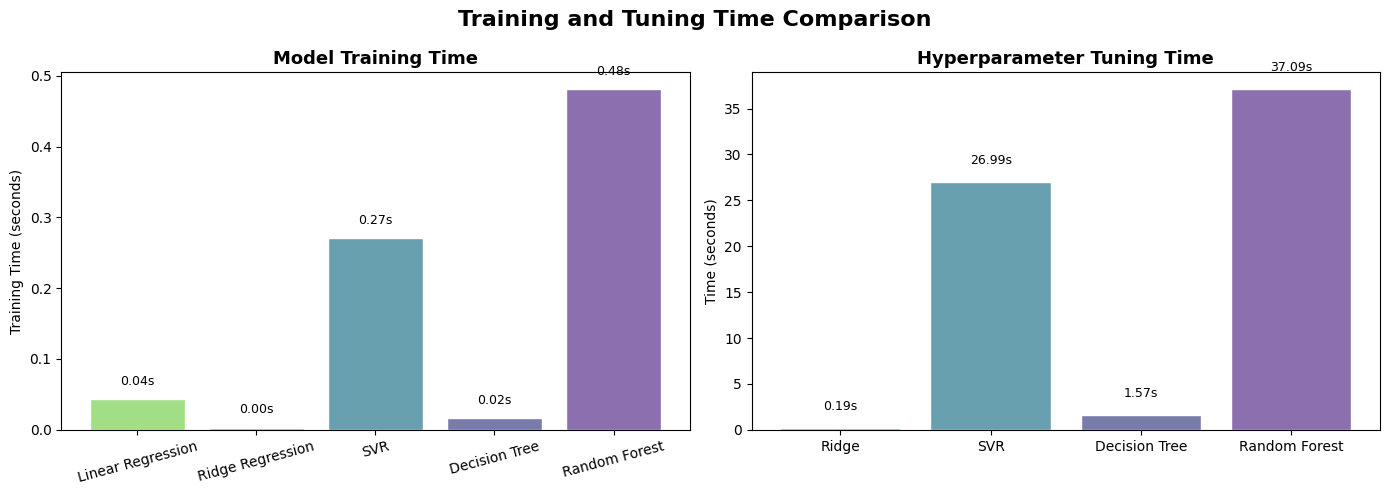

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------------
# Model Training Time
# -------------------------------

axes[0].bar(
    results['Model'],
    results['Training Time (s)'],
    color=colors,
    edgecolor='white'
)

axes[0].set_title(
    'Model Training Time',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_ylabel('Training Time (seconds)')

axes[0].tick_params(axis='x', rotation=15)

for i, v in enumerate(results['Training Time (s)']):

    axes[0].text(
        i,
        v + 0.02,
        f'{v:.2f}s',
        ha='center',
        fontsize=9
    )

# -------------------------------
# Hyperparameter Tuning Time
# -------------------------------

tuning_models = [
    'Ridge',
    'SVR',
    'Decision Tree',
    'Random Forest'
]

tuning_times = [
    ridge_cv_training_time,
    svr_grid_training_time,
    dt_grid_training_time,
    rf_grid_training_time
]

tuning_colors = [
    '#64C2A8',
    '#69A0AF',
    '#797CAA',
    '#8C6FAE'
]

axes[1].bar(
    tuning_models,
    tuning_times,
    color=tuning_colors,
    edgecolor='white'
)

axes[1].set_title(
    'Hyperparameter Tuning Time',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_ylabel('Time (seconds)')

for i, v in enumerate(tuning_times):

    axes[1].text(
        i,
        v + 2,
        f'{v:.2f}s',
        ha='center',
        fontsize=9
    )

plt.suptitle(
    'Training and Tuning Time Comparison',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

### Training and Tuning Time Interpretation

The training time comparison shows that Ridge Regression and Decision Tree were the fastest models to train, requiring almost negligible execution time. Linear Regression also trained very quickly due to its simple mathematical structure.

In contrast, SVR required more training time because kernel-based algorithms are computationally expensive, especially when handling larger datasets. Random Forest recorded the highest training time since it builds multiple decision trees during the learning process.

The hyperparameter tuning results indicate that Random Forest required the longest tuning time, followed by SVR. On the other hand, Ridge Regression and Decision Tree completed tuning much faster due to their smaller parameter search space and lower model complexity.

### Actual vs Predicted CO2 Emissions — Model Comparison


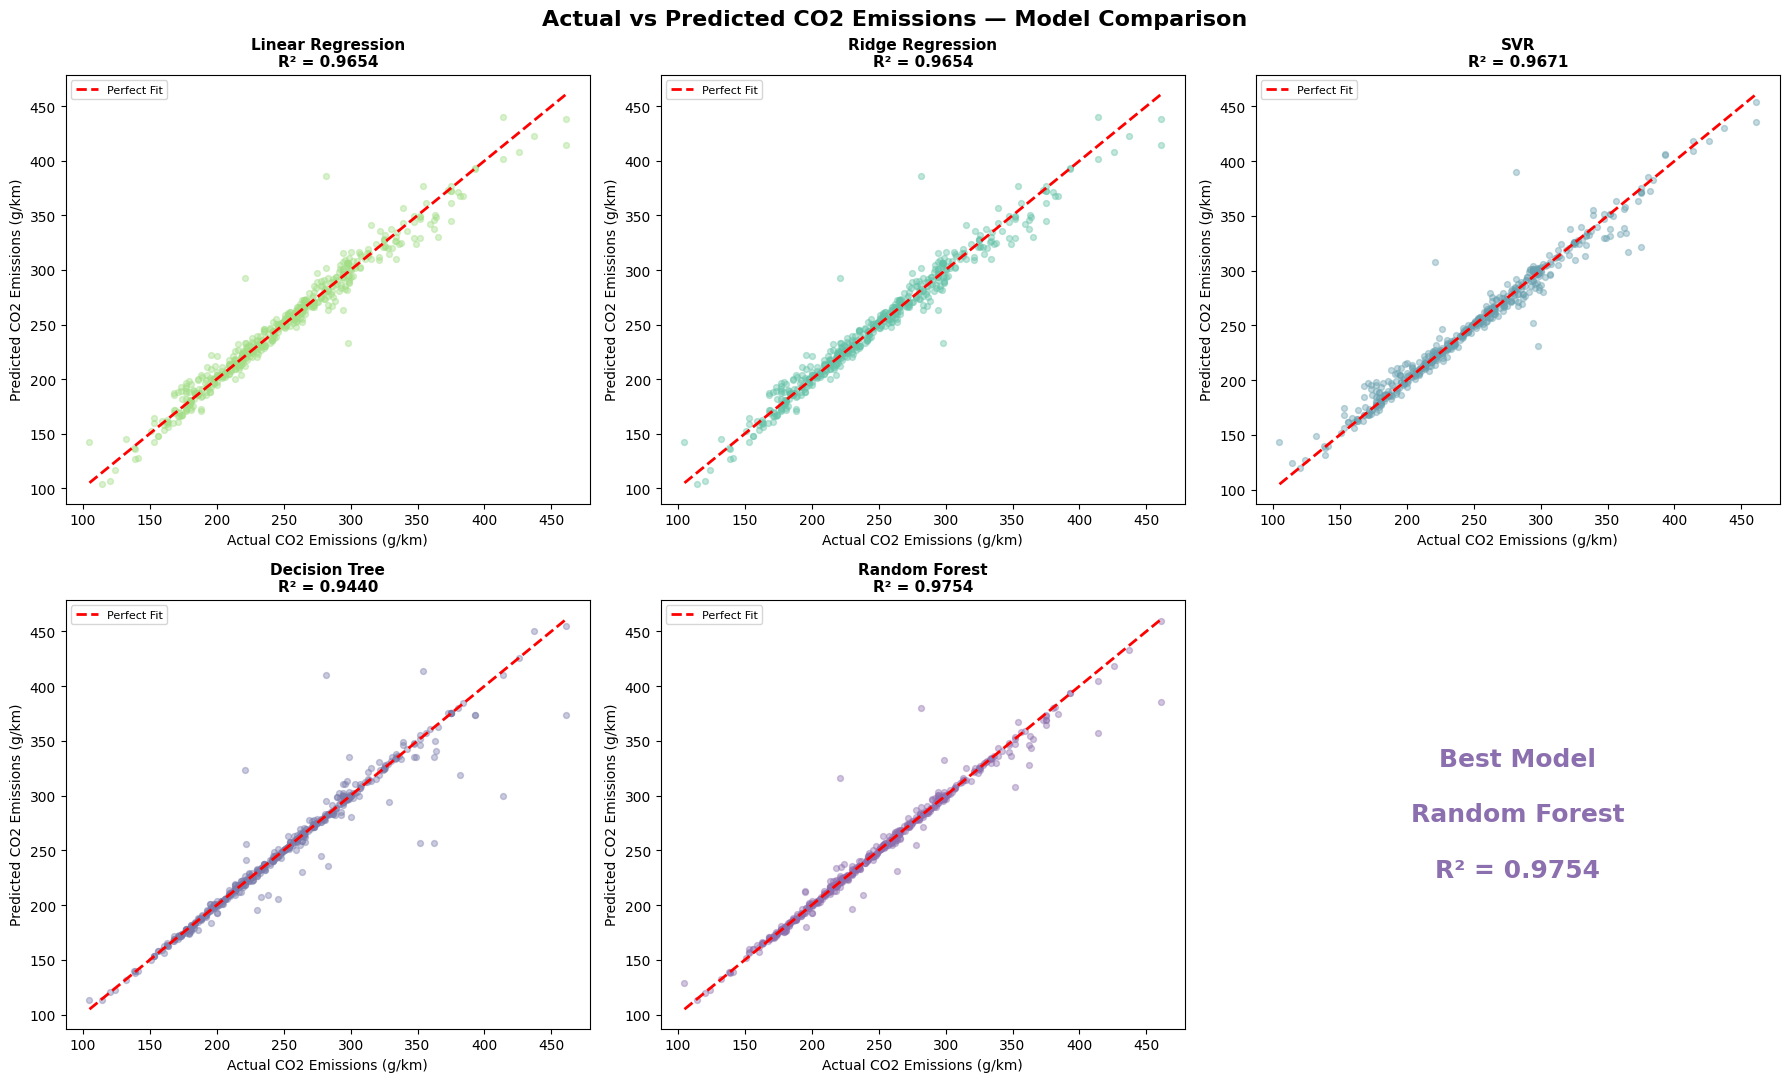

In [92]:
# Actual vs Predicted Plots for All Models

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

axes = axes.flatten()

models = [
    ('Linear Regression', y_pred_linear, linear_r2, '#A1DE85'),
    ('Ridge Regression', y_pred_ridge, ridge_r2, '#64C2A8'),
    ('SVR', y_pred_svr, svr_r2, '#69A0AF'),
    ('Decision Tree', y_pred_dt, dt_r2, '#797CAA'),
    ('Random Forest', y_pred_rf, rf_r2, '#8C6FAE')
]

# Convert y_test to numpy array

y_test_arr = np.array(y_test)

# Min and Max values

min_val = y_test_arr.min()

max_val = y_test_arr.max()

# Find best model automatically

best_model = max(
    models,
    key=lambda x: x[2]
)

best_model_name = best_model[0]

best_model_r2 = best_model[2]

best_model_color = best_model[3]

# Plot each model

for i, (name, predictions, r2, color) in enumerate(models):

    axes[i].scatter(
        y_test_arr,
        predictions,
        alpha=0.4,
        s=18,
        color=color
    )

    # Perfect prediction line

    axes[i].plot(
        [min_val, max_val],
        [min_val, max_val],
        color='red',
        linestyle='--',
        linewidth=2,
        label='Perfect Fit'
    )

    axes[i].set_xlabel(
        'Actual CO2 Emissions (g/km)',
        fontsize=10
    )

    axes[i].set_ylabel(
        'Predicted CO2 Emissions (g/km)',
        fontsize=10
    )

    axes[i].set_title(
        f'{name}\nR² = {r2:.4f}',
        fontsize=11,
        fontweight='bold'
    )

    axes[i].legend(fontsize=8)

# Best model section

axes[5].axis('off')

axes[5].text(
    0.5,
    0.5,
    f'Best Model\n\n{best_model_name}\n\nR² = {best_model_r2:.4f}',
    ha='center',
    va='center',
    fontsize=18,
    fontweight='bold',
    color=best_model_color,
    transform=axes[5].transAxes
)

# Main title

plt.suptitle(
    'Actual vs Predicted CO2 Emissions — Model Comparison',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

The plots above compare the actual CO2 emission values with the predicted values generated by each machine learning model.

The red dashed line represents a perfect prediction line, where predicted values are exactly equal to the actual values. Models with prediction points closer to this line achieve higher accuracy.

#### Key Observations

- Random Forest achieved the best overall performance with the highest R² score (0.9754). The prediction points are highly concentrated around the perfect fit line, indicating strong prediction accuracy and good generalization ability.

- SVR also produced strong results with an R² score of 0.9671. Most prediction points are close to the ideal prediction line, although a small amount of dispersion is still visible compared to Random Forest.

- Linear Regression and Ridge Regression achieved similar performance, both with an R² score of 0.9654. Their prediction points generally follow the perfect fit line, but larger deviations can be observed for some higher CO2 emission values.

- Decision Tree showed the weakest performance among the models with an R² score of 0.9440. The predictions contain more scattered points and noticeable outliers, indicating higher sensitivity to variations in the data.

Overall, the visualization confirms that Random Forest provided the most accurate predictions for vehicle CO2 emissions in this project.

### Residual Plot

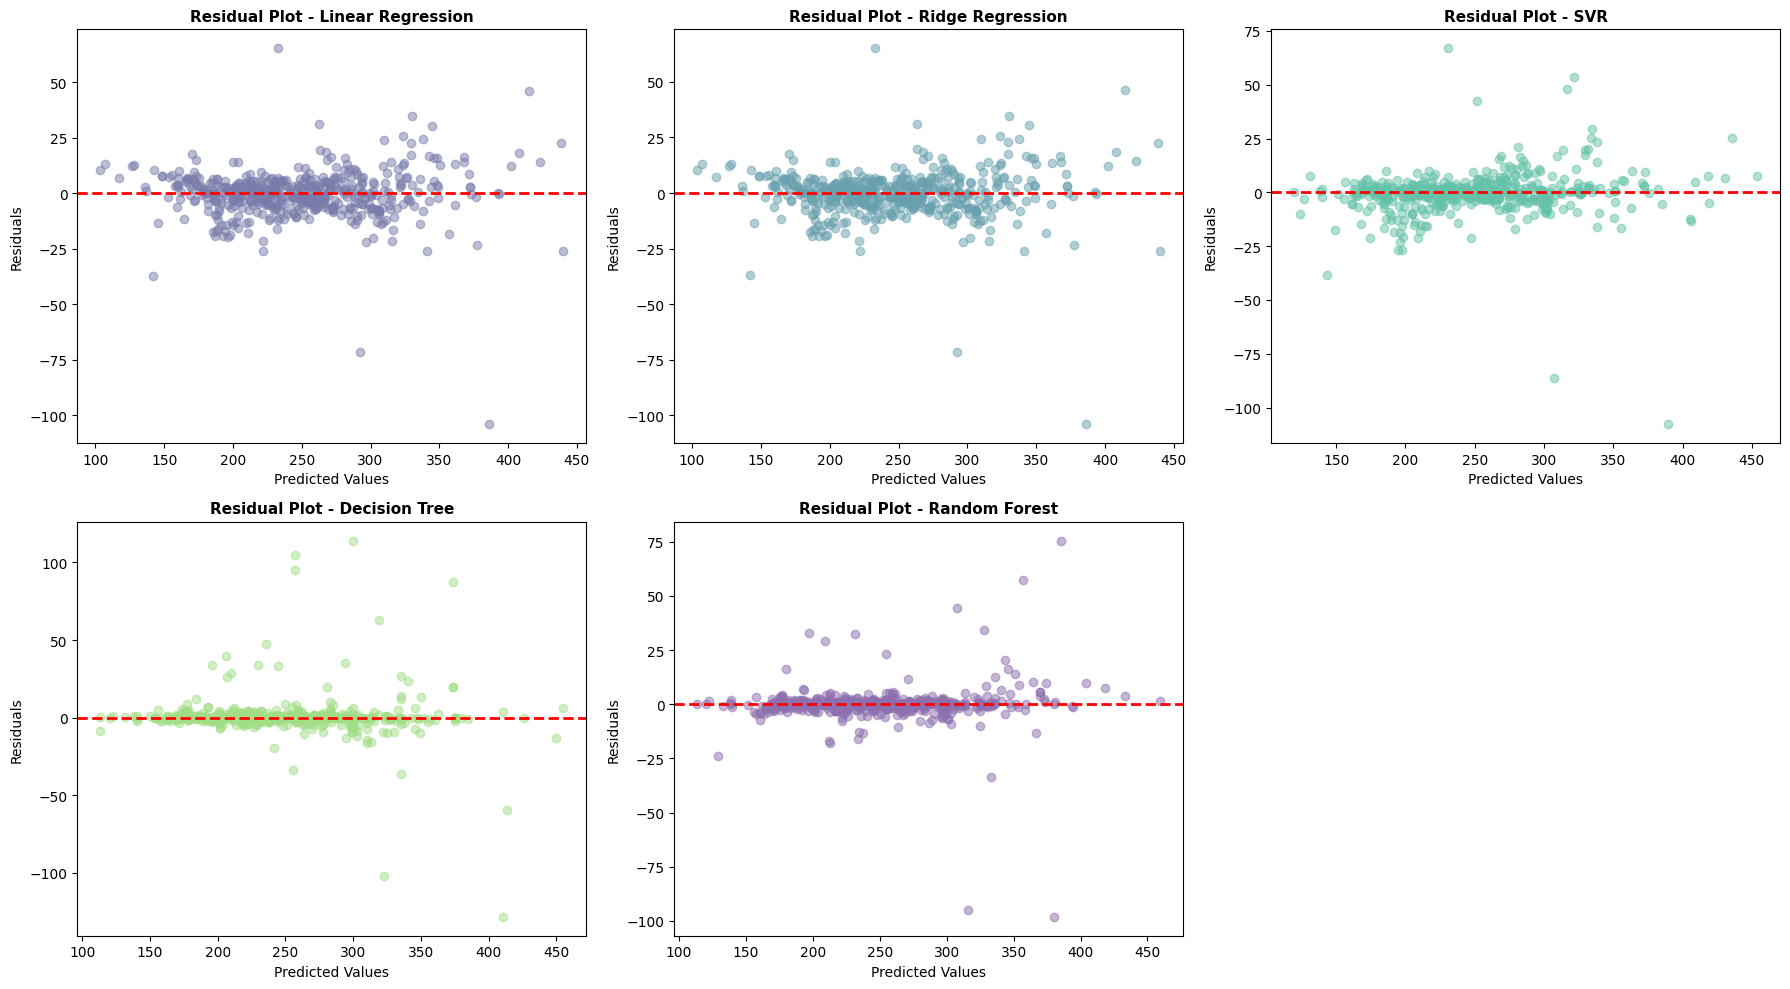

In [93]:
# Residual Plots for All Models

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

models = [
    ('Linear Regression', y_pred_linear, '#797CAA'),
    ('Ridge Regression', y_pred_ridge, '#69A0AF'),
    ('SVR', y_pred_svr, '#64C2A8'),
    ('Decision Tree', y_pred_dt, '#A1DE85'),
    ('Random Forest', y_pred_rf, "#8C6FAE")
]

for i, (name, predictions, color) in enumerate(models):

    residuals = y_test - predictions

    axes[i].scatter(
        predictions,
        residuals,
        alpha=0.5,
        color=color
    )

    axes[i].axhline(
        0,
        color='red',
        linestyle='--',
        linewidth=2
    )

    axes[i].set_title(
        f'Residual Plot - {name}',
        fontsize=11,
        fontweight='bold'
    )

    axes[i].set_xlabel('Predicted Values')

    axes[i].set_ylabel('Residuals')

# Remove empty subplot

fig.delaxes(axes[5])

plt.tight_layout()

plt.show()

The residual plots above show the prediction errors for each machine learning model. Residuals represent the difference between the actual CO2 emission values and the predicted values generated by the models.

The red dashed horizontal line represents zero error. A well-performing model should produce residuals that are randomly distributed around this line with minimal spread.

#### Key Observations

- Linear Regression and Ridge Regression show a wider spread of residuals around the zero line, especially at higher predicted values. Several large positive and negative residuals are visible, indicating that the linear models were less effective at capturing complex patterns in the dataset.

- SVR achieved a better residual distribution, with most residuals concentrated closer to zero compared to the linear models. However, some noticeable outliers still appear, particularly for larger prediction values.

- Decision Tree produced residuals that are highly concentrated near zero for many predictions, but it also contains several extreme outliers with very large residual values. This indicates that the model fit some observations very well while performing poorly on others.

- Random Forest showed the most balanced residual distribution overall. Most residuals are tightly clustered around zero with fewer extreme deviations, demonstrating stable prediction performance and better generalization compared to the other models.

Overall, the residual analysis confirms that Random Forest provided the most stable and reliable prediction performance for vehicle CO2 emissions in this project.

### Feature Importance and Coefficient Analysis

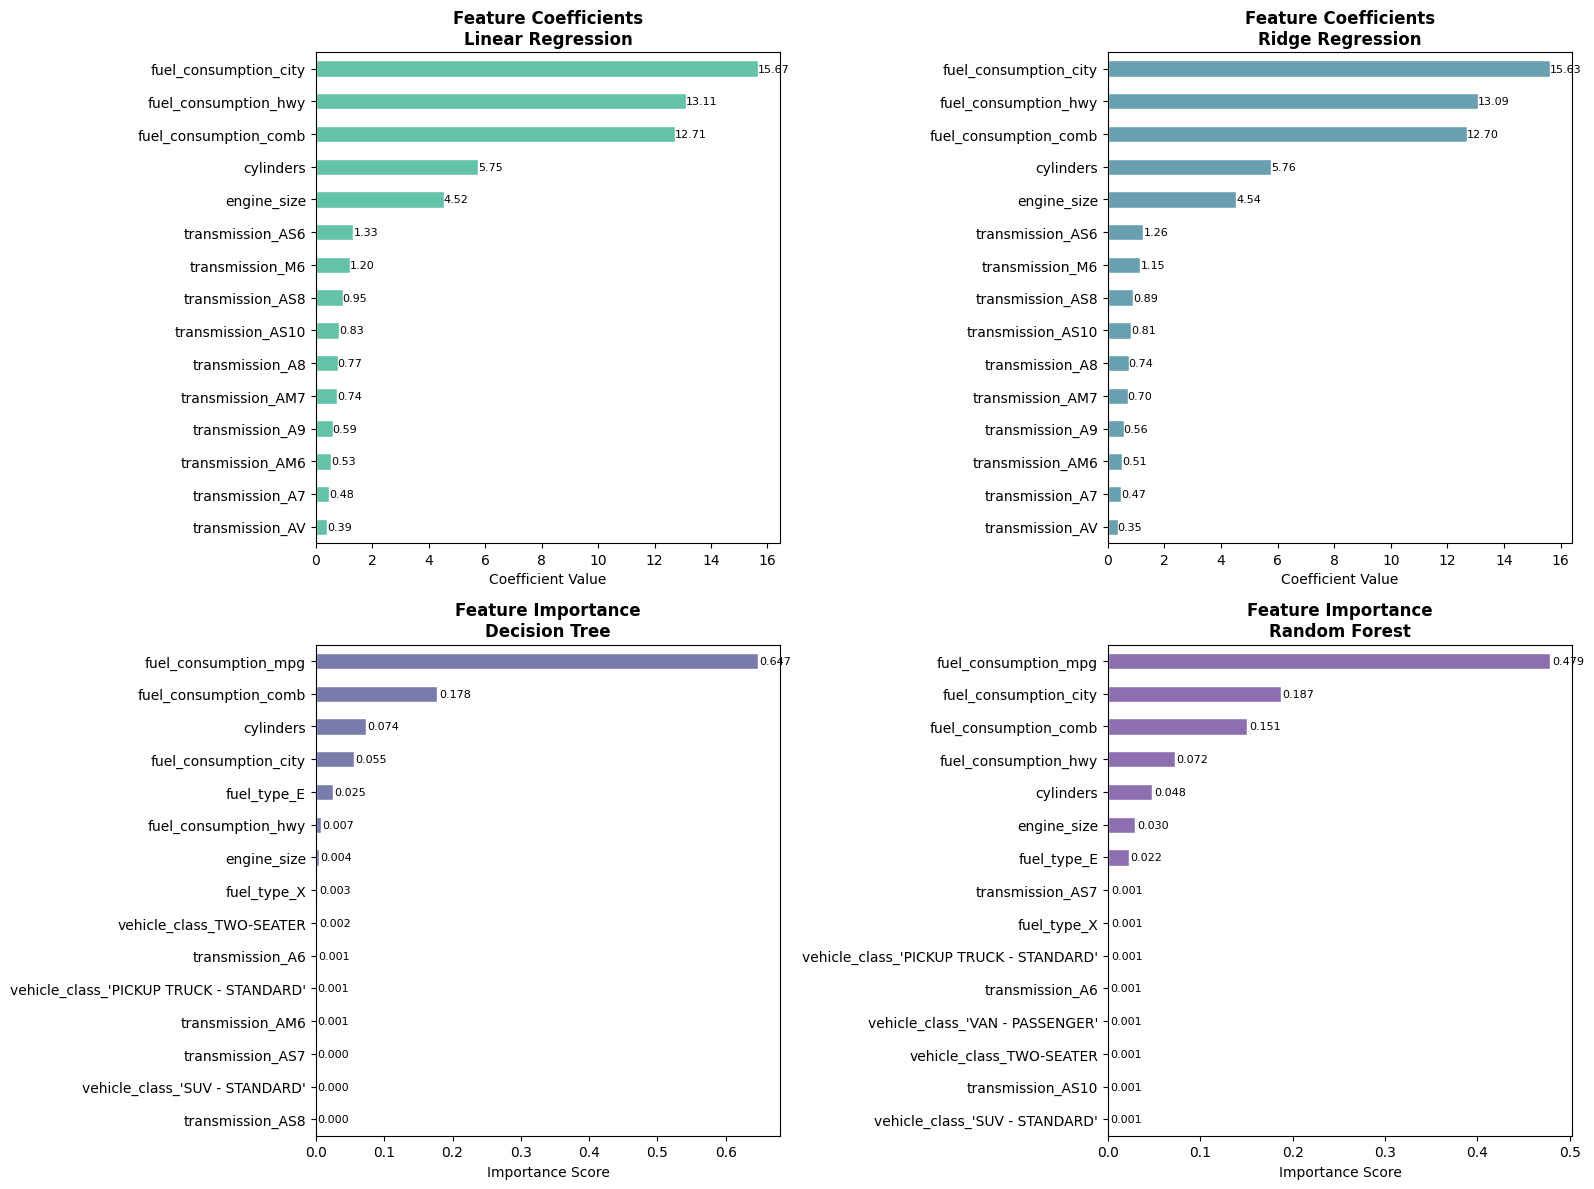

In [94]:
# Feature Importance / Coefficient Comparison for All Models

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes = axes.flatten()

# -------------------------------
# Linear Regression
# -------------------------------

linear_importance = pd.Series(
    linear_model.coef_,
    index=X.columns
)

linear_importance = linear_importance.sort_values().tail(15)

colors_linear = [
    '#64C2A8' if v > 0 else '#E57373'
    for v in linear_importance.values
]

linear_importance.plot(
    kind='barh',
    ax=axes[0],
    color=colors_linear,
    edgecolor='white'
)

axes[0].set_title(
    'Feature Coefficients\nLinear Regression',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel('Coefficient Value')

for patch, val in zip(axes[0].patches, linear_importance.values):

    axes[0].text(
        patch.get_width(),
        patch.get_y() + patch.get_height()/2,
        f'{val:.2f}',
        va='center',
        fontsize=8
    )

# -------------------------------
# Ridge Regression
# -------------------------------

ridge_importance = pd.Series(
    ridge_model.coef_,
    index=X.columns
)

ridge_importance = ridge_importance.sort_values().tail(15)

colors_ridge = [
    '#69A0AF' if v > 0 else '#E57373'
    for v in ridge_importance.values
]

ridge_importance.plot(
    kind='barh',
    ax=axes[1],
    color=colors_ridge,
    edgecolor='white'
)

axes[1].set_title(
    'Feature Coefficients\nRidge Regression',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel('Coefficient Value')

for patch, val in zip(axes[1].patches, ridge_importance.values):

    axes[1].text(
        patch.get_width(),
        patch.get_y() + patch.get_height()/2,
        f'{val:.2f}',
        va='center',
        fontsize=8
    )

# -------------------------------
# Decision Tree
# -------------------------------

dt_importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
)

dt_importance = dt_importance.sort_values(
    ascending=True
).tail(15)

colors_dt = [
    '#797CAA' if v > dt_importance.median()
    else '#D9EAF7'
    for v in dt_importance.values
]

dt_importance.plot(
    kind='barh',
    ax=axes[2],
    color=colors_dt,
    edgecolor='white'
)

axes[2].set_title(
    'Feature Importance\nDecision Tree',
    fontsize=12,
    fontweight='bold'
)

axes[2].set_xlabel('Importance Score')

for patch, val in zip(axes[2].patches, dt_importance.values):

    axes[2].text(
        patch.get_width() + 0.002,
        patch.get_y() + patch.get_height()/2,
        f'{val:.3f}',
        va='center',
        fontsize=8
    )

# -------------------------------
# Random Forest
# -------------------------------

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

rf_importance = rf_importance.sort_values(
    ascending=True
).tail(15)

colors_rf = [
    '#8C6FAE' if v > rf_importance.median()
    else '#D9EAF7'
    for v in rf_importance.values
]

rf_importance.plot(
    kind='barh',
    ax=axes[3],
    color=colors_rf,
    edgecolor='white'
)

axes[3].set_title(
    'Feature Importance\nRandom Forest',
    fontsize=12,
    fontweight='bold'
)

axes[3].set_xlabel('Importance Score')

for patch, val in zip(axes[3].patches, rf_importance.values):

    axes[3].text(
        patch.get_width() + 0.002,
        patch.get_y() + patch.get_height()/2,
        f'{val:.3f}',
        va='center',
        fontsize=8
    )

plt.tight_layout()

plt.show()

The plots above illustrate the most influential features used by each machine learning model for predicting vehicle CO2 emissions.

#### Linear Regression and Ridge Regression

Both Linear Regression and Ridge Regression produced very similar coefficient distributions, showing consistent feature influence across the two models.

The most influential features were:

fuel_consumption_city
fuel_consumption_hwy
fuel_consumption_comb

These features received the highest positive coefficient values, indicating that higher fuel consumption strongly increases predicted CO2 emissions.

In addition, cylinders and engine_size also contributed positively to the prediction process, although their influence was lower compared to fuel consumption variables.

Most transmission-related features had relatively small coefficient values, meaning they had only a limited effect on CO2 emission predictions.

#### Decision Tree Regressor

Decision Tree relied heavily on fuel_consumption_mpg, which received the highest importance score by a large margin. This indicates that the model mainly depended on fuel efficiency measurements when generating predictions.

Other features such as:

fuel_consumption_comb
cylinders
fuel_consumption_city

had smaller contributions compared to the dominant importance of fuel_consumption_mpg.

#### Random Forest Regressor

Random Forest produced a more balanced feature importance distribution compared to Decision Tree.

The most important features included:

fuel_consumption_mpg
fuel_consumption_city
fuel_consumption_comb
fuel_consumption_hwy

Additional features such as cylinders and engine_size also contributed to the prediction process.

This balanced distribution indicates that Random Forest considered multiple features together, which helped improve prediction accuracy and generalization performance.

Overall, fuel consumption related features were consistently identified as the most important predictors of vehicle CO2 emissions across all machine learning models.

## Conclusion

This project explored the prediction of vehicle CO2 emissions using multiple machine learning regression models and a comprehensive vehicle emissions dataset.

Several preprocessing steps were applied, including feature encoding, train-test splitting, and feature scaling for models that require standardized input data. Exploratory Data Analysis (EDA) was also performed to better understand the relationships between vehicle characteristics and CO2 emissions.

Five regression models were trained and evaluated:
- Linear Regression
- Ridge Regression
- Support Vector Regression (SVR)
- Decision Tree Regressor
- Random Forest Regressor

The models were compared using:
- R² Score
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Residual analysis
- Actual vs Predicted visualizations

The experimental results showed that ensemble and non-linear machine learning models achieved the best predictive performance on the dataset. Among all tested models, Random Forest Regressor produced the highest accuracy, achieving the best R² Score and the lowest prediction errors, while also demonstrating strong generalization capability and stable prediction performance.

Feature importance analysis revealed that fuel consumption–related variables were the most influential factors affecting vehicle CO₂ emissions. In particular, features such as fuel_consumption_city, fuel_consumption_comb, and fuel_consumption_mpg showed the strongest contributions across multiple models. Engine size and the number of cylinders also played important roles in predicting emission levels.

Overall, the project demonstrates that machine learning techniques can effectively predict vehicle CO₂ emissions and provide valuable insights into the vehicle characteristics that contribute most significantly to environmental impact and fuel efficiency.